# 6. The memo and its evidence

**Week 1, Tuesday. Chapter 6 of 6.** By the end of this notebook you can test a stakeholder's cause with the data in hand, put a ceiling on what it could explain, and write the memo's claim with two hypotheses and the evidence that would settle each.

> **The tier offers a cause.** "It is the broken reorder button. One of my members says it has been
> broken for six weeks."
>
> The head of Retail-Plus

> **And the CEO wants one page.** "Which branch, which segment, and what you would bet on. Tell me
> what you know and what you are guessing."
>
> Meera Raghavan, CEO, Kalpa Retail

**What chapter 5 established, and what this adds.** Nobody was lost and nobody was new; 18 of the 23
customers who slowed are members; Retail-Plus is 93 percent of the consumer fall, 51 orders to 26 on
the same 22 members. This chapter grows chapter 1's accumulator into a counting function that takes
any key, by month or by channel, and uses it to test the cause the head of Retail-Plus hands us.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Business", "Student"]
groups = {"Q1": {}, "Q2": {}}       # quarter -> segment -> list of orders
by_quarter = {"Q1": [], "Q2": []}
for order in ORDERS:
    q, seg = order["quarter"], order["segment"]
    groups[q].setdefault(seg, []).append(order)
    by_quarter[q].append(order)


def tree_for(rows):
    """The revenue tree's leaves for any list of orders, returned as a dictionary (chapter 3)."""
    revenue = 0
    seen = {}
    for order in rows:
        revenue += order["amount"]
        seen[order["customer_id"]] = True
    orders = len(rows)
    customers = len(seen)
    return {"revenue": revenue, "orders": orders, "customers": customers,
            "orders_per_customer": orders / customers,
            "revenue_per_order": revenue / orders}


def describe(amounts):
    """A group's typical value and spread: median, min, max and range (chapter 3)."""
    ordered = sorted(amounts)
    n = len(ordered)
    if n % 2 == 1:
        median = ordered[n // 2]
    else:
        median = (ordered[n // 2 - 1] + ordered[n // 2]) / 2
    return {"median": median, "min": ordered[0], "max": ordered[-1], "range": ordered[-1] - ordered[0]}

from datetime import date, timedelta


def pct_change(before, after):
    """Chapter 5's fixed helper: the change every time, in the same type."""
    return round(100 * (after - before) / before, 1)


def count_by(rows, key):
    """Chapter 1's accumulator, grown: count the rows under whatever key(row) returns."""
    counts = {}
    for row in rows:
        k = key(row)
        counts[k] = counts.get(k, 0) + 1
    return counts

plus = [o for o in ORDERS if o["segment"] == "Retail-Plus"]
core = [o for o in ORDERS if o["segment"] == "Retail-Core"]
print(len(plus), "Retail-Plus orders and", len(core), "Retail-Core orders across both quarters")

77 Retail-Plus orders and 74 Retail-Core orders across both quarters


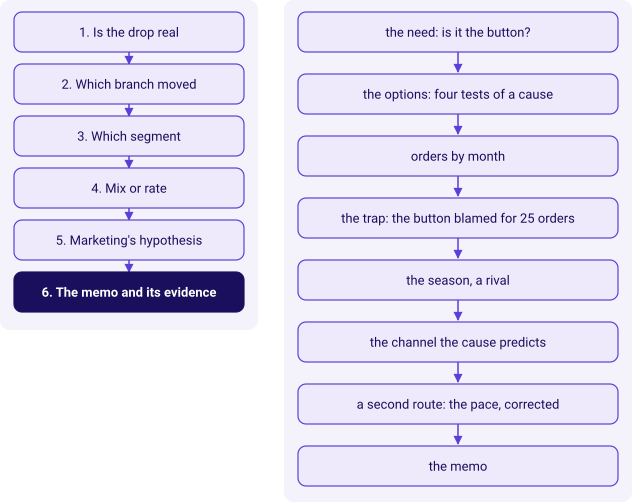

In [2]:
kit.side_by_side(
    kit.ladder(['Is the drop real', 'Which branch moved', 'Which segment', 'Mix or rate', "Marketing's hypothesis", 'The memo and its evidence'], lit=5, show=False),
    kit.vflow(['the need: is it the button?', 'the options: four tests of a cause', 'orders by month', 'the trap: the button blamed for 25 orders', 'the season, a rival', 'the channel the cause predicts', 'a second route: the pace, corrected', 'the memo'], show=False),
)

## The need

The head of Retail-Plus wants engineering to fix the reorder button now and wants the fall in his
tier put down to it. The metric at stake is Retail-Plus orders per week, before and after the date
the button broke. The decision riding on it is two things: what goes to engineering first, and what
Meera is told caused the fall. A wrong answer costs a quarter: blame the button for everything, fix
it, and the tier keeps falling for a reason nobody looked for; or dismiss it, and members keep
failing to reorder.

**Who else faces this.** Sonos rolled out a redesigned app in 2024. Its chief executive said the problems customers and partners met with the new app had
required the company to reduce its fiscal 2024 guidance, and its annual report set aside short-term
costs of up to $30 million to fix the app (Sonos, third quarter fiscal 2024 results and fiscal 2024
annual report, checked 30 Sep 2026). A loyal customer base, an app whose rollout went wrong, and a company that put it into its guidance: the head of Retail-Plus is asking whether his
tier is the same story.

## The options

Four ways to test a cause with the data in hand, and one way beyond it.

| Option | How | What it can rule out |
|---|---|---|
| A. Before and after the break | Retail-Plus orders per week before 25 August and after | The button as the whole story, if the fall began before it broke |
| B. A comparison segment | Retail-Core over the same months | A season or a market that hit every customer |
| C. The channel it predicts | A broken app feature can only stop app orders | An app-only cause, if the web and the store fell too |
| D. The app's logs | Reorder attempts and failures by week, and the release that broke it | Nothing today: a data request, days away |

The cell below sizes each on this file: rows read, and the verdict each one can reach today.

Option,Rows read,Needs,Can reach today
A. before and after,77,the break date,a ceiling on the button's share
B. comparison segment,151,a segment the cause cannot touch,season in or out
C. the channel,77,the channel field,app-only in or out
D. the app's logs,0,a data request,"the settlement, later"


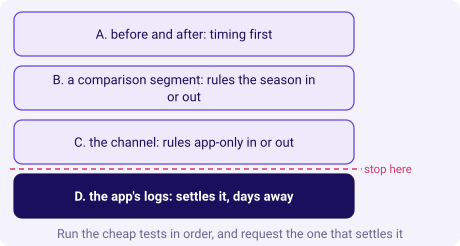

In [3]:
BREAK = (date(2026, 10, 6) - timedelta(weeks=6)).isoformat()      # "six weeks", taken at its word
kit.table(["Option", "Rows read", "Needs", "Can reach today"],
          [("A. before and after", len([o for o in plus if o["quarter"] == "Q2"]) + len([o for o in plus if o["quarter"] == "Q1"]), "the break date", "a ceiling on the button's share"),
           ("B. comparison segment", len(plus) + len(core), "a segment the cause cannot touch", "season in or out"),
           ("C. the channel", len(plus), "the channel field", "app-only in or out"),
           ("D. the app's logs", 0, "a data request", "the settlement, later")],
          caption=f"Sizing four tests; the break is taken as {BREAK}")
kit.decision_ladder(["D. the app's logs: settles it, days away", "C. the channel: rules app-only in or out",
                     "B. a comparison segment: rules the season in or out", "A. before and after: timing first"],
                    cut_at=0, title="Run the cheap tests in order, and request the one that settles it")
kit.check("the break date is 25 August", BREAK == "2026-08-25")

**The best-fit call.** A, B and C now, in that order, because each reads the export already open and
timing comes first, since a cause cannot come after its effect; D requested today, because only the
logs settle it. **The fact that would change the call:** if the complaint's date turned out to be
wrong, say the button broke in June, option A's verdict flips, and the request for the release date
in option D is how we would find out.

## 1. Orders by month: the tier stepped down in July

**Predict before you run.** When did Retail-Plus orders drop below every Q1 month? a) in September,
after the break; b) in August, when the button broke; c) in July, before it broke; d) they never did.

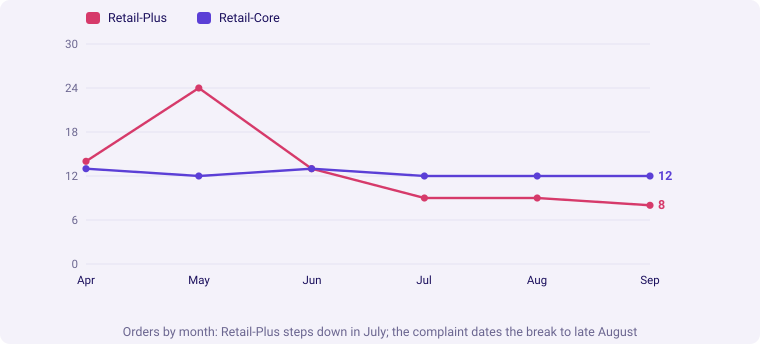

In [4]:
plus_month = count_by(plus, lambda o: o["order_date"][:7])
core_month = count_by(core, lambda o: o["order_date"][:7])
months = sorted(plus_month)
kit.line(["Apr", "May", "Jun", "Jul", "Aug", "Sep"],
         [("Retail-Plus", [plus_month[m] for m in months], "bad"), ("Retail-Core", [core_month.get(m, 0) for m in months], "plain")],
         title="Orders by month: Retail-Plus steps down in July; the complaint dates the break to late August")
kit.check("the months run April to September", months == ["2026-04", "2026-05", "2026-06", "2026-07", "2026-08", "2026-09"])
kit.check("Retail-Plus July sits below every Q1 month", plus_month["2026-07"] < min(plus_month[m] for m in months[:3]))

**What happened.** The answer is c. Retail-Plus orders were down in July, weeks before the late-August
break the complaint dates. The button may still matter; it cannot be the whole story.

## 2. The trap: the button blamed for all 25 orders

**The plausible wrong answer.** A hurried analyst puts the tier's whole fall in the memo as the
button's cost: 51 orders in Q1, 26 in Q2, so the button cost 25 orders and Rs 65,250.

In [5]:
q1_plus = len([o for o in plus if o["quarter"] == "Q1"])
q2_plus = len([o for o in plus if o["quarter"] == "Q2"])
wrong_orders = q1_plus - q2_plus
wrong_rupees = sum(o["amount"] for o in plus if o["quarter"] == "Q1") - sum(o["amount"] for o in plus if o["quarter"] == "Q2")
kit.stats([(str(wrong_orders), "orders the button 'cost'", "Q1 total less Q2 total"),
           (kit.rupees(wrong_rupees), "rupees the button 'cost'", "the whole tier's fall"),
           ("0", "days checked before the break", "the check that is missing")])
kit.check("the hurried memo blames the button for 25 orders and Rs 65,250", (wrong_orders, wrong_rupees) == (25, 65250))

**Why it is wrong.** The comparison spans the whole quarter, so it charges the button with every
order lost since 1 July, including the eight weeks or so before it broke. Engineering would be told the fix
recovers 25 orders a quarter, and when it ships and recovers a handful, the tier's real problem has
had another quarter to run. **The check** splits Q2 at the break and gives each side its window, as
chapter 1 taught: a rate per week, with dates.

Window,Days,Orders,Orders per week
"Q1, 1 Apr to 30 Jun",91,51,3.92
"Q2, 1 Jul to 24 Aug",55,18,2.29
"Q2, 25 Aug to 30 Sep",37,8,1.51


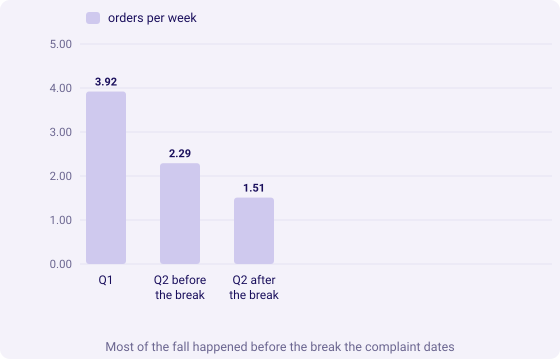

In [6]:
days_q1 = 91
days_before = (date.fromisoformat(BREAK) - date(2026, 7, 1)).days
days_after = (date(2026, 9, 30) - date.fromisoformat(BREAK)).days + 1
before = len([o for o in plus if o["quarter"] == "Q2" and o["order_date"] < BREAK])
after = q2_plus - before
per_week = {"Q1": q1_plus / days_q1 * 7, "before": before / days_before * 7, "after": after / days_after * 7}
kit.table(["Window", "Days", "Orders", "Orders per week"],
          [("Q1, 1 Apr to 30 Jun", days_q1, q1_plus, f'{per_week["Q1"]:.2f}'),
           ("Q2, 1 Jul to 24 Aug", days_before, before, f'{per_week["before"]:.2f}'),
           ("Q2, 25 Aug to 30 Sep", days_after, after, f'{per_week["after"]:.2f}')],
          caption="Retail-Plus orders per week, split at the break")
kit.columns(["Q1", "Q2 before the break", "Q2 after the break"],
            [("orders per week", [round(per_week["Q1"], 2), round(per_week["before"], 2), round(per_week["after"], 2)])],
            fmt=lambda v: f"{v:.2f}", width=560, title="Most of the fall happened before the break the complaint dates")
kit.check("18 Retail-Plus orders before the break and 8 after", (before, after) == (18, 8))
kit.check("the weekly rate had already fallen by more than a third before the break",
          per_week["before"] < per_week["Q1"] * 2 / 3, f'{per_week["Q1"]:.2f} to {per_week["before"]:.2f}')

**The fix.** Charge the button with no more than the fall after the break beyond the pace the tier
had already dropped to. At the pre-break pace of 18 orders in 55 days, the 37 days after the break
would have carried about 12.1 orders; the tier placed 8. So the button explains at most about 4 orders
in the quarter, about Rs 12,400 at Q2's Retail-Plus revenue per order, and it is a ceiling, since
anything else that kept worsening would claim part of it.

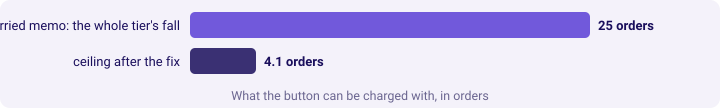

In [7]:
ceiling = (before / days_before - after / days_after) * days_after
plus_rpo_q2 = tree_for(groups["Q2"]["Retail-Plus"])["revenue_per_order"]
kit.bars([("hurried memo: the whole tier's fall", wrong_orders), ("ceiling after the fix", round(ceiling, 1))],
         fmt=lambda v: f"{v:g} orders", lit=[1], title="What the button can be charged with, in orders")
kit.check("the button explains at most about 4.1 orders", round(ceiling, 1) == 4.1, f"{ceiling:.2f}")
kit.check("the ceiling is worth about Rs 12,400", round(ceiling * plus_rpo_q2, -2) == 12400, kit.rupees(round(ceiling * plus_rpo_q2)))

**What changed.** "The button cost 25 orders, Rs 65,250" became "the fall began in July, before the
break; the button can explain at most about 4 orders, about Rs 12,400, and the rest needs another
cause". Engineering still fixes the button; the memo stops promising it fixes the tier.

## 3. The season, a rival to every cause

July opens the monsoon quarter, so a seasonal dip would also begin in July. A season that hit every
customer would move the comparison segment too.

**Predict before you run.** Retail-Core kept what share of its Q1 orders in Q2? a) about half, like
Retail-Plus; b) about three quarters; c) about 95 percent; d) more than all of them.

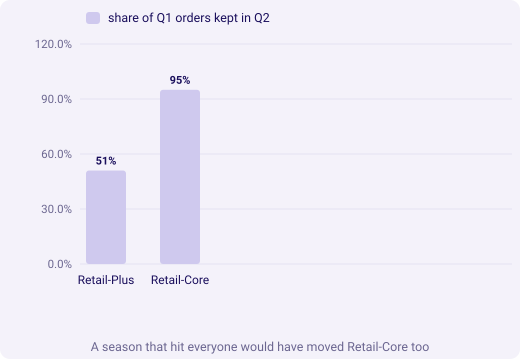

In [8]:
core_ratio = len([o for o in core if o["quarter"] == "Q2"]) / len([o for o in core if o["quarter"] == "Q1"])
plus_ratio = q2_plus / q1_plus
kit.columns(["Retail-Plus", "Retail-Core"], [("share of Q1 orders kept in Q2", [round(plus_ratio * 100), round(core_ratio * 100)])],
            fmt=lambda v: f"{v}%", width=520, title="A season that hit everyone would have moved Retail-Core too")
kit.check("Retail-Core kept more than nine tenths of its Q1 orders", core_ratio > 0.9, f"{core_ratio:.2f}")
kit.check("Retail-Plus kept about half", 0.45 < plus_ratio < 0.55, f"{plus_ratio:.2f}")

**What happened.** The answer is c. Retail-Core kept 95 percent of its Q1 orders and Retail-Plus 51,
so a season that hit every customer does not fit. A season that hit members harder still fits, and
only last year's Q2 by segment rules it out; it goes on the data request.

## 4. The channel the cause predicts

A broken app feature can only stop orders placed through the app. If it were the whole cause, the app
would have fallen and the web and the store would have held.

**Predict before you run.** Which Retail-Plus channels fell between Q1 and Q2? a) only the app; b)
the app and the web; c) every channel; d) none.

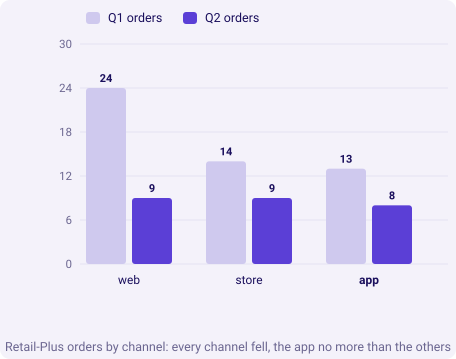

In [9]:
by_channel = {q: count_by([o for o in plus if o["quarter"] == q], lambda o: o["channel"]) for q in ("Q1", "Q2")}
CHANNELS = ["web", "store", "app"]
fell = {ch: by_channel["Q2"][ch] < by_channel["Q1"][ch] for ch in CHANNELS}
kit.columns(CHANNELS, [("Q1 orders", [by_channel["Q1"][c] for c in CHANNELS]), ("Q2 orders", [by_channel["Q2"][c] for c in CHANNELS])],
            lit=[2], title="Retail-Plus orders by channel: every channel fell, the app no more than the others")
kit.check("every channel fell", fell == {"web": True, "store": True, "app": True}, str(fell))
kit.check("the app fell by a smaller share than the web", by_channel["Q2"]["app"] / by_channel["Q1"]["app"] > by_channel["Q2"]["web"] / by_channel["Q1"]["web"])

**What happened.** The answer is c. The web fell from 24 to 9, the store from 14 to 9, and the app
from 13 to 8. An app-only cause predicts the app falling first and alone, and it did not; something
touched members in every channel.

## A second route: the pace, corrected by a segment the button cannot touch

Section 2's ceiling assumed the tier would have kept its pre-break pace. An independent check asks
what happened across the same date to Retail-Core, which the button did not touch because the
complaint is about members' reorders. If every customer slowed a little after 25 August, part of the
tier's shortfall belongs to that and not to the button. Scale the tier's expected orders by
Retail-Core's own change in pace across the break, then compare with what the tier placed. If the
button were the only thing moving, this route would give the same 4.1 orders; if something else
slowed every customer, it gives fewer, which is why section 2's figure is a ceiling.

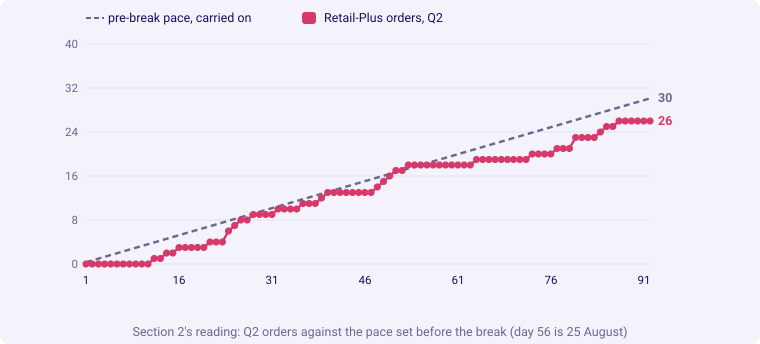

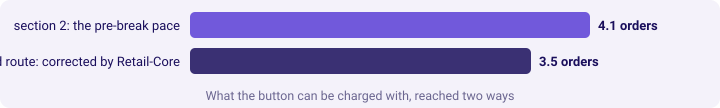

In [10]:
core_before = len([o for o in core if o["quarter"] == "Q2" and o["order_date"] < BREAK])
core_after = len([o for o in core if o["quarter"] == "Q2"]) - core_before
core_change = (core_after / days_after) / (core_before / days_before)
route_two = before / days_before * days_after * core_change - after
cum_days = list(range(1, 93))
q2_dates = sorted(date.fromisoformat(o["order_date"]) for o in plus if o["quarter"] == "Q2")
actual_cum = [sum(1 for d in q2_dates if (d - date(2026, 7, 1)).days < n) for n in cum_days]
pace_cum = [round(before / days_before * n, 2) for n in cum_days]
kit.line([str(n) if n % 15 == 1 else "" for n in cum_days],
         [("pre-break pace, carried on", pace_cum, "plan"), ("Retail-Plus orders, Q2", actual_cum, "bad")],
         fmt=lambda v: f"{v:.0f}", title="Section 2's reading: Q2 orders against the pace set before the break (day 56 is 25 August)")
kit.bars([("section 2: the pre-break pace", round(ceiling, 1)), ("second route: corrected by Retail-Core", round(route_two, 1))],
         fmt=lambda v: f"{v:g} orders", lit=[1], title="What the button can be charged with, reached two ways")
kit.check("Retail-Core placed 22 orders before the break and 14 after", (core_before, core_after) == (22, 14))
kit.check("the corrected route charges the button no more than the ceiling", 0 < route_two <= ceiling, f"{route_two:.2f}")

**When to switch.** Write section 2's ceiling in the memo, since it assumes nothing about any other
segment; bring the corrected route when someone argues for the season, since it takes out what hit
Retail-Core as well. Here it charges the button with about 3.5 orders, inside the ceiling of about 4.

## The memo: the claim and the evidence that settles each hypothesis

Neither cause is proved or disproved by this export. Each is a hypothesis, and each is settled by data
Kalpa holds elsewhere.

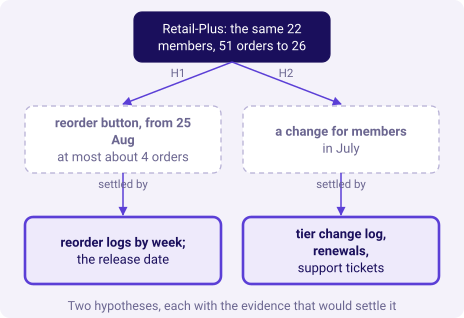

In [11]:
EVIDENCE = {
    "export": "orders per customer by segment from this export, again",
    "campaigns": "Marketing's new-customer campaign reach by month",
    "app_logs": "the app's reorder attempts and failures by week, the release that broke it, and whether members who used reorder in Q1 fell more",
    "tier_log": "the tier's change log for benefits, prices and delivery terms in July, renewals, and members' support tickets",
    "last_year": "last year's Q1 and Q2 orders by segment",
}
HYPOTHESES = {"H1, the reorder button deepened the fall after 25 August": "app_logs",
              "H2, something changed for members in July": "tier_log",
              "Rival, a monsoon dip that hit members harder": "last_year"}
kit.tree({"label": "Retail-Plus: the same 22 members, 51 orders to 26", "kind": "lit", "branches": [
    ("H1", {"label": "reorder button, from 25 Aug\nat most about 4 orders", "kind": "unknown", "branches": [
        ("settled by", {"label": "reorder logs by week;\nthe release date", "kind": "known"})]}),
    ("H2", {"label": "a change for members\nin July", "kind": "unknown", "branches": [
        ("settled by", {"label": "tier change log, renewals,\nsupport tickets", "kind": "known"})]})]},
    title="Two hypotheses, each with the evidence that would settle it")
kit.check("every hypothesis is settled by data this export does not carry",
          all(v not in ("export", "campaigns") for v in HYPOTHESES.values()))
kit.check("no two hypotheses share their evidence", len(set(HYPOTHESES.values())) == len(HYPOTHESES))

**The memo's claim, as it goes to Meera and the head of Retail-Plus.** "Revenue fell 11.0 percent
between two closed quarters, Rs 2.10 crore to Rs 1.87 crore on the export as it stands. Customers held
at 69, all of them buying in both quarters, so acquisition is not the branch that moved; orders per
customer fell from 1.65 to 1.25. In behaviour the fall sits in Retail-Plus, where the same 22 members
placed 26 orders against 51, and revenue per order rose mainly because those small orders
disappeared. In rupees most of the fall is three fewer Business orders, each worth lakhs and too few to call a trend. The fall began in July, before the reorder button broke,
and hit every channel, so the button can explain at most about 4 orders. Two hypotheses remain: the
button deepened the fall after 25 August, settled by the app's reorder logs by week and the release
date; and something changed for members in July, settled by the tier's change log, renewals and
support tickets. Last year's Q2 by segment rules the season in or out. We are asking for all three."

> **Kavya's review.** "You gave the head of Retail-Plus a number for his cause, a ceiling of about 4
> orders, instead of a yes or a no. That is what a hypothesis looks like when it is handled well.
> Now say what you know and what you are guessing, in that order, and stop."

### In the interview

**[D] A stakeholder hands you a cause; how do you test it with the data you have and name the data
you need?** "I restate it as a hypothesis with a mechanism and test what the mechanism predicts,
timing first, since a cause cannot come after its effect. The broken reorder button predicted a fall
starting in late August and sitting in the app; the data shows a fall that began in July and hit
every channel. That does not rule the button out; it caps it, here at about 4 orders. Then I name the
data that settles it, the reorder logs by week and the release date, and a second hypothesis with its
own evidence." The interviewer is listening for predictions tested against timing, a ceiling, and a
named data request.

**[S] Sales dropped; what goes in the one-page memo?** "The confirmed size on matched windows, the
branch with its rupees, the segment with its denominator, what the obvious readings got wrong, and
each cause as a hypothesis with the evidence that would settle it. What we know comes first and what
we are guessing second, and each guess carries its test." The interviewer is listening for the
separation of fact from hypothesis.

**The design question. Which test of a cause do you run first, and when do you stop testing and ask
for new data?** "Timing first, because it is cheap and can rule a cause out outright; then a
comparison group, for the season; then the channel the cause predicts. I stop when the export can only
cap a cause, not settle it, and then the request names the exact data: here the reorder logs by week."
The interviewer is listening for an order with a reason, and a stopping rule.

### Depth: logs that cannot see their own failures

A failure log that records only the attempts that reached the server misses every member whose tap
never got that far, so the members most hurt by a break may be the ones the log cannot see. That
absence is not random, which is chapter 2's missing discount field in a new place. Ask which system
writes the log, and what it does when the app never calls it.

The ceiling also rests on a baseline: the tier's pace over all 55 days from 1 July to the break. Try
it: take only the 37 days just before the break as the baseline, the same length as the window after
it, and recompute the ceiling. Say which baseline you would defend to the head of Retail-Plus, and
why the memo has to name the one it used.

References for the chapter:

- Sonos, "Sonos Reports Third Quarter Fiscal 2024 Results": https://investors.sonos.com/news-and-events/investor-news/latest-news/2024/Sonos-Reports-Third-Quarter-Fiscal-2024-Results/ (verified 30 Sep 2026)
- Brit Institute, data analyst case study questions: https://britinstitute.uk/blog/data-analyst-case-study-interview-questions (verified 29 Sep 2026)

In [12]:
kit.check_summary()
print("Next: the escalated case, the whole ladder again on the orders that reached customers.")

Next: the escalated case, the whole ladder again on the orders that reached customers.
